# Driven exciton: light-induced spin torque in the rotating frame

Under a coherent drive at $\omega_L$ near the bright exciton, the single-mode theory of `BrightExcitonMode` + `ExcitonSpinSusceptibility` simplifies drastically in the frame rotating at the laser frequency: the exciton pole is effectively **shifted from $E_X$ to the detuning**

$$\Delta(x)=E_X(x)-\omega_L,$$

so a near-resonant drive moves it down to magnon frequencies (with the linewidth $\kappa$ as a floor). The slow-spin moments — which in equilibrium are suppressed by inverse powers of $E_X$ — are then controlled by inverse powers of $\Delta$, and the drive supplies a coherent exciton population $n_X$ that multiplies everything.

This also collapses the multifrequency-vertex problem deferred in `LightInducedExcitonTorque`: the mode-projected vertex is the frequency-independent coupling $g_0=dE_X/dx=-\Delta_B/2$ (Hellmann–Feynman), so the full $\Omega$-dependent light-induced kernel is closed-form, parametrized by the measurable numbers $(\Delta_B, E_X, \kappa)$ plus the drive.

Everything here is analytic — no $k$-sums; the microscopic constants enter only through the calibrated closed forms.

In [16]:
using Printf
using PyPlot

rc("font", family="serif")
rc("font", size=13)
rc("axes", labelsize=14, titlesize=14)
rc("legend", fontsize=10)

# -----------------------------
# Single-mode parameters from the calibrated closed forms (eV)
# -----------------------------
γ_c = 0.40; γ_v = 0.40
Δ_0 = 2.0
Jpd_v = 0.069; Jpd_c = 0.031
V_intra = 1.708; V_inter = 0.691

γ_cv = 2 * (γ_c + γ_v)
Jt = Jpd_c + Jpd_v
δV = (V_intra - V_inter) / 2
εbar = sqrt(γ_cv^2 + V_intra^2)
EX_AFM = Δ_0 + Jt + γ_cv - εbar
ΔB = Jt^2 / 2 * (3εbar^2 - V_intra^2) / (εbar * V_intra^2) +
     Jt^2 / (2δV) * V_inter * εbar / V_intra^2
g0 = -ΔB / 2                      # exciton-magnetization coupling dE_X/dx
EX(θ) = EX_AFM - (ΔB / 2) * (1 + cos(θ))

# Drive parameters: we parametrize by the MEASURED coherent exciton density
# n_X (excitons per site), the experimental knob (fluence-controlled, as in
# arXiv:2409.18501). The implied drive amplitude is f² = n_X (Δ² + κ²/4);
# the linear regime f << κ then bounds the detuning: |Δ| ≲ κ/√n_X.
κ = 0.004                         # exciton linewidth (decay rate), eV; κ = 2η, τ_X = ħ/κ
n_X = 0.04                        # coherent excitons per site

f_implied(Δ) = sqrt(n_X * (Δ^2 + κ^2 / 4))
@printf("E_X(AFM) = %.5f eV ; ΔB = %.2f meV ; g0 = %.2f meV ; κ = %.1f meV ; n_X = %.3f\n",
        EX_AFM, 1e3ΔB, 1e3g0, 1e3κ, n_X)
@printf("implied drive: f(Δ=0) = %.2f meV ; f = κ reached at |Δ| = %.1f κ (validity bound)\n",
        1e3 * f_implied(0.0), sqrt(1 / n_X - 0.25));

E_X(AFM) = 1.35964 eV ; ΔB = 15.35 meV ; g0 = -7.67 meV ; κ = 4.0 meV ; n_X = 0.040
implied drive: f(Δ=0) = 0.40 meV ; f = κ reached at |Δ| = 5.0 κ (validity bound)


## Rotating frame, coherent amplitude, fluctuation kernel

In the frame rotating at $\omega_L$ (rotating-wave approximation for the drive),

$$\tilde H=\Delta(x)\,b^\dagger b+f\,(b^\dagger+b),\qquad \Delta(x)=E_X(x)-\omega_L,$$

with amplitude decay $\kappa/2$ ($\kappa=2\eta$, the exciton linewidth). The steady coherent amplitude gives the exciton population

$$\beta=\frac{-if}{\kappa/2+i\Delta},\qquad n_X=|\beta|^2=\frac{f^2}{\Delta^2+\kappa^2/4},$$

and since the response depends on the drive only through $n_X$, we use the **measured exciton density** as the input parameter — the implied amplitude $f^2=n_X(\Delta^2+\kappa^2/4)$ stays in the linear regime $f\ll\kappa$ for $|\Delta|\lesssim\kappa/\sqrt{n_X}$.

Writing $b=\beta+\delta b$ in the coupling $g_0\,x\,b^\dagger b$, the term linear in the fluctuation, $g_0x(\beta^*\delta b+\beta\,\delta b^\dagger)$, lets the slow coordinate $x$ exchange weight with the **driven exciton fluctuation**, whose pole sits at $\Delta$. Solving the fluctuation equations of motion for a slow modulation $x(t)=x_\Omega e^{-i\Omega t}+{\rm c.c.}$ gives the drive-induced kernel acting on $x$:

$$\Sigma(\Omega)=-g_0^2\,n_X\left[\frac{1}{\Omega-\Delta+i\kappa/2}-\frac{1}{\Omega+\Delta+i\kappa/2}\right],$$

the same resonant $+$ anti-resonant structure as the equilibrium kernels, satisfying (R1)–(R2) by construction. The coherent population also exerts the static term $-g_0n_X$, which enters with the contact ($\delta_{ab}$) spin structure exactly like the equilibrium contact term. The driven contribution to the spin response is therefore

$$R^{\rm drive}_{12,ab}(\Omega)=M_2^aM_1^b\,\Sigma(\Omega)\;-\;\delta_{ab}\,g_0\,n_X,$$

and the slow-spin moments follow as in the equilibrium section:

$$J^{\rm drive}_{\rm pole}=\Sigma(0)=\frac{2\Delta\,g_0^2n_X}{\Delta^2+\kappa^2/4},\qquad
J^{\rm drive}_{\rm cont}=-g_0n_X=\frac{\Delta_B}{2}n_X\;\;(\Delta\text{-independent}),$$

$$\boxed{\;\alpha^{\rm drive}={\rm Im}\,\partial_\Omega\Sigma\big|_0
=\frac{2\kappa\,\Delta\,g_0^2\,n_X}{(\Delta^2+\kappa^2/4)^2}.\;}$$

**Sign physics**: $\alpha^{\rm drive}\propto\Delta$ — driving below the exciton ($\omega_L<E_X$, $\Delta>0$) **damps** the magnon; driving above ($\Delta<0$) **anti-damps** it (magnon gain). At fixed density the damping is extremal at $\Delta^*=\pm\kappa/(2\sqrt3)$. The light-induced exchange $J_{\rm pole}$ flips sign with detuning too: light-controlled FM$\leftrightarrow$AFM interlayer coupling.

In [17]:
# -----------------------------
# Driven kernel, moments, and validation (fixed exciton density n_X)
# -----------------------------
G2 = g0^2 * n_X
Σdr(Ω, Δ) = -G2 * (1 / (Ω - Δ + im * κ / 2) - 1 / (Ω + Δ + im * κ / 2))

Jpole_dr(Δ) = 2Δ * G2 / (Δ^2 + κ^2 / 4)
Jcont_dr = -g0 * n_X
α_dr(Δ) = 2κ * Δ * G2 / (Δ^2 + κ^2 / 4)^2
α_ω(ω, Δ) = imag(Σdr(ω, Δ)) / ω          # finite-frequency damping kernel

# checks
Δt = κ
@printf("(R1) Σ(0) = %.3e %+.1e im   (real)\n", real(Σdr(0, Δt)), imag(Σdr(0, Δt)))
@printf("(R2) max|Σ(-ω)* - Σ(ω)| = %.2e\n",
        maximum(abs(conj(Σdr(-ω, Δt)) - Σdr(ω, Δt)) for ω in range(-0.02, 0.02, length=201)))
δΩ = 1e-7
@printf("α: numeric dΣ/dΩ = %+.5e  vs closed = %+.5e\n",
        imag((Σdr(δΩ, Δt) - Σdr(-δΩ, Δt)) / (2δΩ)), α_dr(Δt))
@printf("J(0) consistency: Σ(0) = %.5e  vs closed J_pole = %.5e\n", real(Σdr(0, Δt)), Jpole_dr(Δt))

Δscan = range(0.01κ, 3κ, length=3000)
Δstar_num = Δscan[argmax([α_dr(Δ) for Δ in Δscan])]
@printf("optimum (fixed n_X): numeric Δ* = %.4f κ  vs analytic κ/2√3 = %.4f κ\n",
        Δstar_num / κ, 1 / (2sqrt(3)))
Δstar = κ / (2sqrt(3))
α_eq = κ * ΔB / EX_AFM^3                  # equilibrium contact damping (η = κ/2)
@printf("α_drive(Δ*) = %.3e ; equilibrium α = %.3e ; ENHANCEMENT = %.1e\n",
        α_dr(Δstar), α_eq, α_dr(Δstar) / α_eq)
@printf("implied drive at Δ*: f = %.3f meV = %.2f κ  (linear regime OK)\n",
        1e3 * f_implied(Δstar), f_implied(Δstar) / κ)

(R1) Σ(0) = 9.423e-04 -0.0e+00 im   (real)
(R2) max|Σ(-ω)* - Σ(ω)| = 0.00e+00
α: numeric dΣ/dΩ = +1.88450e-01  vs closed = +1.88450e-01
J(0) consistency: Σ(0) = 9.42252e-04  vs closed J_pole = 9.42252e-04
optimum (fixed n_X): numeric Δ* = 0.2892 κ  vs analytic κ/2√3 = 0.2887 κ
α_drive(Δ*) = 7.650e-01 ; equilibrium α = 2.443e-05 ; ENHANCEMENT = 3.1e+04
implied drive at Δ*: f = 0.462 meV = 0.12 κ  (linear regime OK)


## Figure 1: damping and light-induced exchange vs detuning

At fixed exciton density. Left: the damping moment $\alpha^{\rm drive}(\Delta)$ — odd in detuning (below resonance damps, above anti-damps), extremal at $\pm\kappa/2\sqrt3$, with the equilibrium damping shown for scale (invisible: four orders of magnitude smaller). Right: the two light-induced exchange contributions — the dispersive pole part (odd in $\Delta$) and the contact part, which at fixed density is a **constant** $\frac{\Delta_B}{2}n_X$ (the absorption profile is absorbed into holding $n_X$ fixed).

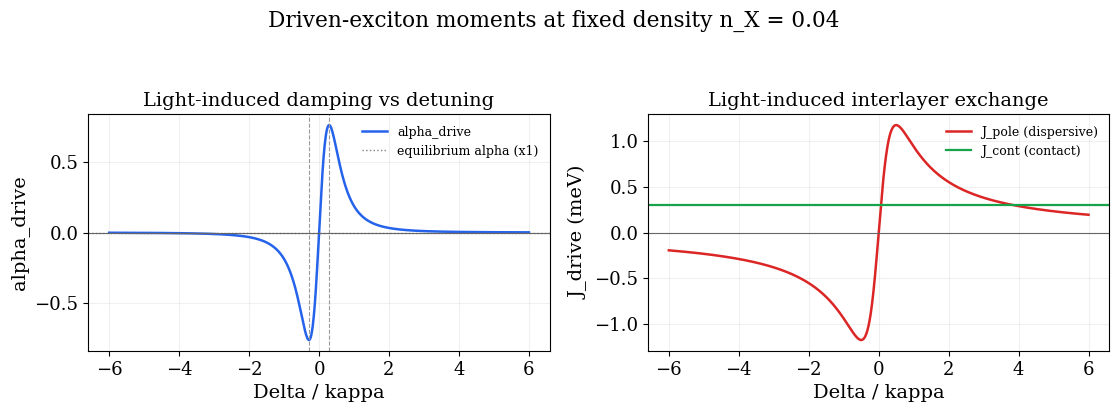

In [18]:
Δs = collect(range(-6κ, 6κ, length=1201))

fig, axs = subplots(1, 2, figsize=(11.5, 4.2))
axs[1].plot(Δs ./ κ, [α_dr(Δ) for Δ in Δs], lw=1.8, color="#2563eb", label="alpha_drive")
axs[1].axhline(α_eq, color="gray", lw=1.0, ls=":", label="equilibrium alpha (x1)")
axs[1].axvline(1 / (2sqrt(3)), color="0.6", lw=0.8, ls="--")
axs[1].axvline(-1 / (2sqrt(3)), color="0.6", lw=0.8, ls="--")
axs[1].axhline(0.0, color="0.4", lw=0.8)
axs[1].set_xlabel("Delta / kappa")
axs[1].set_ylabel("alpha_drive")
axs[1].set_title("Light-induced damping vs detuning")
axs[1].grid(alpha=0.18)
axs[1].legend(frameon=false, fontsize=9)

axs[2].plot(Δs ./ κ, 1e3 .* [Jpole_dr(Δ) for Δ in Δs], lw=1.8, color="#dc2626", label="J_pole (dispersive)")
axs[2].axhline(1e3 * Jcont_dr, color="#16a34a", lw=1.6, label="J_cont (contact)")
axs[2].axhline(0.0, color="0.4", lw=0.8)
axs[2].set_xlabel("Delta / kappa")
axs[2].set_ylabel("J_drive (meV)")
axs[2].set_title("Light-induced interlayer exchange")
axs[2].grid(alpha=0.18)
axs[2].legend(frameon=false, fontsize=9)
fig.suptitle("Driven-exciton moments at fixed density n_X = " * string(n_X))
fig.tight_layout(rect=(0, 0, 1, 0.93))

## Figure 2: finite magnon frequency

Beyond the Taylor expansion, the damping kernel at the actual magnon frequency is $\alpha(\omega_m;\Delta)={\rm Im}\,\Sigma(\omega_m)/\omega_m$: a two-Lorentzian structure with resonances at $\Delta=\pm\omega_m$, where the magnon exchanges weight with the driven exciton fluctuation most efficiently. For CrSBr the magnon ($\sim25$ GHz $\approx0.1$ meV) satisfies $\omega_m\ll\kappa$, so the two resonances merge and the Taylor $\alpha$ is accurate; the curves show how the resolved structure would emerge for stiffer modes.

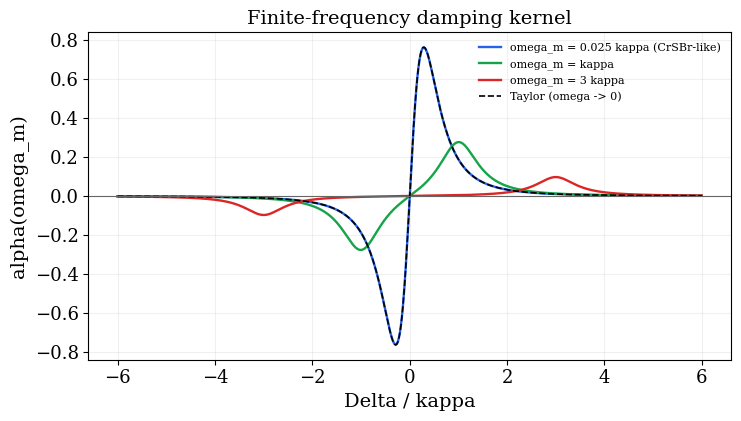

In [19]:
fig, ax = subplots(figsize=(7.6, 4.4))
for (ωm, col, lbl) in [(0.025κ, "#2563eb", "omega_m = 0.025 kappa (CrSBr-like)"),
                       (κ, "#16a34a", "omega_m = kappa"),
                       (3κ, "#dc2626", "omega_m = 3 kappa")]
    ax.plot(Δs ./ κ, [α_ω(ωm, Δ) for Δ in Δs], lw=1.7, color=col, label=lbl)
end
ax.plot(Δs ./ κ, [α_dr(Δ) for Δ in Δs], lw=1.2, ls="--", color="black", label="Taylor (omega -> 0)")
ax.axhline(0.0, color="0.4", lw=0.8)
ax.set_xlabel("Delta / kappa")
ax.set_ylabel("alpha(omega_m)")
ax.set_title("Finite-frequency damping kernel")
ax.grid(alpha=0.18)
ax.legend(frameon=false, fontsize=8)
fig.tight_layout()

## Figure 3: the damping landscape $\alpha(\theta,\omega_L)$

The detuning is **angle-dependent through the exciton line**, $\Delta(\theta)=E_X(\theta)-\omega_L$ with $E_X(\theta)=E_X^{\rm AFM}-\frac{\Delta_B}{2}(1+\cos\theta)$. Sweeping the laser across the angular dispersion of the exciton produces a damping/anti-damping boundary that **tracks $E_X(\theta)$**: at fixed $\omega_L$, rotating the moments through the resonance flips the sign of the light-induced torque — and conversely the laser color selects at which magnetic configuration the magnon is damped or amplified. The map shows the **scalar kernel** $\alpha^{\rm drive}$ vs $(\theta,\omega_L)$ — the spin structure $M_2^aM_1^b$ is factored out (next section) — **at fixed exciton density** (experimentally: fluence adjusted to keep the measured density constant); the dashed line is $\omega_L=E_X(\theta)$.

Note the map is finite on **both** sides of the exciton line: the coherent amplitude is a driven response, not on-resonance absorption, and the dissipation comes from magnon-assisted scattering $\omega_L\to\omega_L\pm\omega_m$ sampling the Lorentzian tails of the exciton line — it decays as $1/\Delta^3$ but never vanishes. The dotted lines mark the fixed-density validity boundary $|\Delta|=\kappa\sqrt{1/n_X-1/4}$ (where the implied drive reaches $f=\kappa$): outside it the linear treatment fails, and physically the far tails also depend on the true (non-Lorentzian) lineshape.

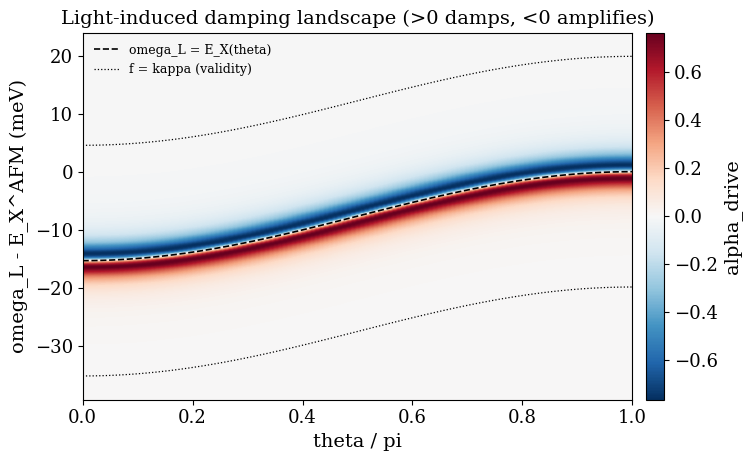

In [20]:
θs_dr = collect(range(0.0, stop=π, length=121))
ωLs = collect(range(EX_AFM - ΔB - 6κ, EX_AFM + 6κ, length=321))
α_map = [α_dr(EX(θ) - ωL) for ωL in ωLs, θ in θs_dr]

fig, ax = subplots(figsize=(7.8, 4.8))
vmax = maximum(abs, α_map)
img = ax.imshow(α_map, origin="lower", aspect="auto",
                extent=(θs_dr[1] / π, θs_dr[end] / π, 1e3 * (ωLs[1] - EX_AFM), 1e3 * (ωLs[end] - EX_AFM)),
                cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.plot(θs_dr ./ π, 1e3 .* (EX.(θs_dr) .- EX_AFM), color="black", lw=1.2, ls="--", label="omega_L = E_X(theta)")
# linear-drive validity boundary at fixed density: |Δ| = κ√(1/n_X - 1/4)  (f = κ)
Δbound = κ * sqrt(1 / n_X - 0.25)
ax.plot(θs_dr ./ π, 1e3 .* (EX.(θs_dr) .- Δbound .- EX_AFM), color="black", lw=0.9, ls=":", label="f = kappa (validity)")
ax.plot(θs_dr ./ π, 1e3 .* (EX.(θs_dr) .+ Δbound .- EX_AFM), color="black", lw=0.9, ls=":")
ax.set_xlabel("theta / pi")
ax.set_ylabel("omega_L - E_X^AFM (meV)")
ax.set_title("Light-induced damping landscape (>0 damps, <0 amplifies)")
ax.legend(frameon=false, fontsize=9, loc="upper left")
cbar = fig.colorbar(img, ax=ax, pad=0.02)
cbar.set_label("alpha_drive")
fig.tight_layout()

## Angle dependence of the magnitude: the damping tensor

The scalar map above varies with $\theta$ only through the detuning. The **magnitude** of the physical susceptibility components carries additional angle dependence:

1. **Spin structure** (dominant): $\alpha_{12,ab}(\theta,\omega_L)=M_2^a(\theta)M_1^b(\theta)\,\alpha^{\rm drive}$. Since the static contact term $-g_0n_X\delta_{ab}$ does not contribute to damping, the light-induced damping tensor is **purely** of $M_2M_1$ type — fully anisotropic, in sharp contrast with the equilibrium damping, which was contact-dominated and nearly isotropic. Components switch off at the collinear configurations ($zz\propto\cos^2(\theta/2)$ dies toward AFM, $xx\propto-\sin^2(\theta/2)$ toward FM, $xz/zx\propto\mp\sin\theta/2$ at both ends).
2. **Exact coupling** $g_0(\theta)=dE_X/dx$: beyond the linear law it varies by $\sim4\%$ across the sweep ($\mathcal O(J_+^4)$); it enters squared. The maps below use the exact implicit slope and the exact pole $E_X(\theta)$ (closed-form root of $F_s$, no $k$-sums).
3. **Oscillator strength**: at fixed *density* the $\theta$-dependence of the exciton's optical coupling ($Z_X$, mode composition) is absorbed into the implied fluence; at fixed *fluence* the absorption profile $n_X\propto[\Delta(\theta)^2+\kappa^2/4]^{-1}$ would reappear as an extra magnitude factor.

exact g0(θ): -7.674 .. -7.328 meV (linear-law -ΔB/2 = -7.674) ; E_X exact vs closed max diff 0.354 meV


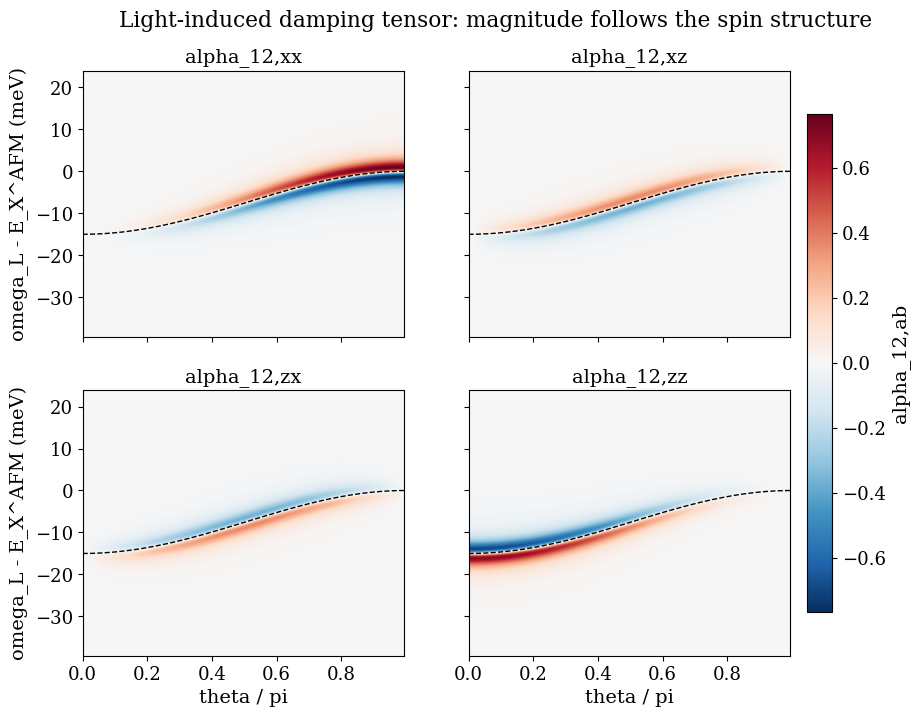

PyObject Text(0.5, 0.96, 'Light-induced damping tensor: magnitude follows the spin structure')

In [21]:
# -----------------------------
# Exact E_X(θ) and g0(θ) from the closed-form pole equation (no k-sums)
# -----------------------------
E0_pair = Δ_0 + Jt
J_plus(θ) = Jt * cos(θ/2)

function gpack(Ω, Eedge)
    center = Eedge + γ_cv
    u = (center - Ω)^2 - γ_cv^2
    (Ω < center - γ_cv && u > 0) || return (NaN, NaN, NaN)
    return (-1 / sqrt(u), -(center - Ω) * u^(-1.5), (center - Ω) * u^(-1.5))
end

function EX_and_slope(θ)
    Ja = abs(J_plus(θ))
    Vav = 0.5 * (V_intra + V_inter)
    le = E0_pair - Ja
    F(Ω) = begin
        gm, _, _ = gpack(Ω, E0_pair - Ja)
        gp, _, _ = gpack(Ω, E0_pair + Ja)
        (isfinite(gm) && isfinite(gp)) ? 1 + Vav * (gm + gp) + V_intra * V_inter * gm * gp : NaN
    end
    xs = range(le - 5, le - 1e-9, length=8000)
    xp = xs[1]; Fp = F(xp); EXr = NaN
    for x in xs[2:end]
        Fx = F(x)
        if isfinite(Fp) && isfinite(Fx) && Fp * Fx < 0
            lo, hi = xp, x
            for _ in 1:80
                mid = (lo + hi) / 2; Fm = F(mid)
                (isfinite(Fm) && Fp * Fm <= 0) ? (hi = mid) : (lo = mid; Fp = Fm)
            end
            EXr = (lo + hi) / 2
            break
        end
        xp = x; Fp = Fx
    end
    gm, gΩm, gcm = gpack(EXr, E0_pair - Ja)
    gp, gΩp, gcp = gpack(EXr, E0_pair + Ja)
    am = V_intra * V_inter * gp + Vav
    ap = V_intra * V_inter * gm + Vav
    dEXdc = Jt * (-(am * (-gcm) + ap * gcp) / (am * gΩm + ap * gΩp))
    return (; EX=EXr, dEXdx=dEXdc / (4 * cos(θ/2)))
end

mhat1(θ) = [sin(θ/2), 0.0, cos(θ/2)]
mhat2(θ) = [-sin(θ/2), 0.0, cos(θ/2)]

θs_tn = collect(range(0.0, stop=0.995π, length=121))
slopes_tn = [EX_and_slope(θ) for θ in θs_tn]
EX_tn = [s.EX for s in slopes_tn]
g0_tn = [s.dEXdx for s in slopes_tn]
@printf("exact g0(θ): %.3f .. %.3f meV (linear-law -ΔB/2 = %.3f) ; E_X exact vs closed max diff %.3f meV\n",
        1e3 * minimum(g0_tn), 1e3 * maximum(g0_tn), -1e3 * ΔB / 2,
        1e3 * maximum(abs.(EX_tn .- EX.(θs_tn))))

α_scalar(Δ, g) = 2κ * Δ * g^2 * n_X / (Δ^2 + κ^2 / 4)^2

comps_tn = [(1, 1, "xx"), (1, 3, "xz"), (3, 1, "zx"), (3, 3, "zz")]
α_tensor_maps = [[mhat2(θs_tn[iθ])[a] * mhat1(θs_tn[iθ])[b] *
                  α_scalar(EX_tn[iθ] - ωLs[iω], g0_tn[iθ])
                  for iω in eachindex(ωLs), iθ in eachindex(θs_tn)]
                 for (a, b, _) in comps_tn]

fig, axs = subplots(2, 2, figsize=(11.0, 7.6), sharex=true, sharey=true)
axs_flat = vec(permutedims(axs))
vmax_tn = maximum(M -> maximum(abs, M), α_tensor_maps)
img = nothing
for (j, (a, b, lbl)) in enumerate(comps_tn)
    ax = axs_flat[j]
    img = ax.imshow(α_tensor_maps[j], origin="lower", aspect="auto",
                    extent=(θs_tn[1] / π, θs_tn[end] / π, 1e3 * (ωLs[1] - EX_AFM), 1e3 * (ωLs[end] - EX_AFM)),
                    cmap="RdBu_r", vmin=-vmax_tn, vmax=vmax_tn)
    ax.plot(θs_tn ./ π, 1e3 .* (EX_tn .- EX_AFM), color="black", lw=1.0, ls="--")
    ax.set_title("alpha_12," * lbl)
    ax.grid(false)
end
for ax in axs[:, 1]
    ax.set_ylabel("omega_L - E_X^AFM (meV)")
end
for ax in axs[end, :]
    ax.set_xlabel("theta / pi")
end
cbar = fig.colorbar(img, ax=vec(axs), shrink=0.85, pad=0.02)
cbar.set_label("alpha_12,ab")
fig.suptitle("Light-induced damping tensor: magnitude follows the spin structure", y=0.96)

## Estimates, caveats, next steps

**Magnitude.** With $\kappa=4$ meV and a measured coherent density $n_X=4\times10^{-2}$ excitons per site, the light-induced damping at optimal detuning exceeds the equilibrium (virtual-exciton) damping by $\sim10^4$. The mechanism is the one anticipated by the equilibrium analysis: the moments scale as inverse powers of the pole position, and the drive replaces $E_X\to\max(\Delta,\kappa/2)\sim$ meV, while supplying the population factor $n_X$. Both knobs are experimental: $n_X$ from the fluence, $\Delta$ from the laser color.

**Validity.**
- *Linear drive*: $f\ll\kappa$; at fixed density this bounds the detuning, $|\Delta|\lesssim\kappa/\sqrt{n_X}$ ($\simeq5\kappa$ here) — beyond it the pole is split, not just shifted.
- *Coherent-only*: the displaced-state treatment keeps the coherent amplitude; incoherent exciton occupation and its fluctuations require the Keldysh structure deferred in `StaticSpinSucep`/`LightInducedExcitonTorque`.
- *Single mode*: CT pole, dark sector, and continuum neglected — good near resonance where the bright pole dominates (unlike the static equilibrium moments).
- *CW limit*: a pulse of duration $\tau\gg1/\kappa$ behaves adiabatically; shorter pulses give transient (impulsive) torques.
- The global normalization $C$ and the LLG projection ($\gamma/M_s$, torque geometry) are shared with the equilibrium moments.

**Relation to `LightInducedExcitonTorque`**: the kernels here are the single-mode reduction of the deferred $R^{I/II,\rm light}(\Omega)$ — the multifrequency vertices $\Lambda(\nu+\Omega,\nu)$ collapse to the constant $g_0$ by Hellmann–Feynman, making the full response-frequency dependence explicit with no extra numerics.